In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pickle
from matplotlib.colors import ListedColormap
import pandas as pd
from PIL import Image
from sklearn.cluster import KMeans
from skimage.filters.rank import modal
from skimage.morphology import disk
from scipy.ndimage import center_of_mass
from scipy.spatial.distance import cdist

In [2]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [3]:

# Parameters
SHAPE = (100, 100)
MEANS = [12, 15, 19, 23, 26]
STDS = [2, 1.5, 1.25, 1.75, 2]

# Generate Gaussian matrices
gaussian_matrices = [
    np.random.normal(loc=mean, scale=std, size=SHAPE)
    for mean, std in zip(MEANS, STDS)
]

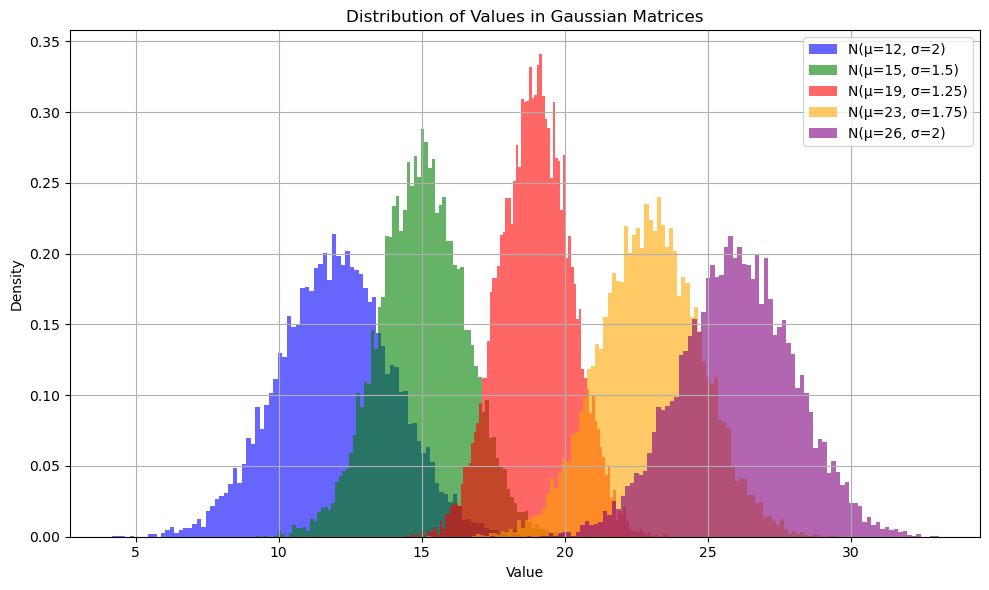

In [4]:
# Plot settings
COLORS = ["blue", "green", "red", "orange", "purple"]
labels = [f"N(μ={mean}, σ={std})" for mean, std in zip(MEANS, STDS)]

# Create figure
plt.figure(figsize=(10, 6))

# Plot histograms
for matrix, color, label in zip(gaussian_matrices, COLORS, labels):
    plt.hist(
        matrix.ravel(),
        bins=100,
        alpha=0.6,
        color=color,
        label=label,
        density=True,
    )

# Titles and labels
plt.title("Distribution of Values in Gaussian Matrices")
plt.xlabel("Value")
plt.ylabel("Density")

# Layout
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

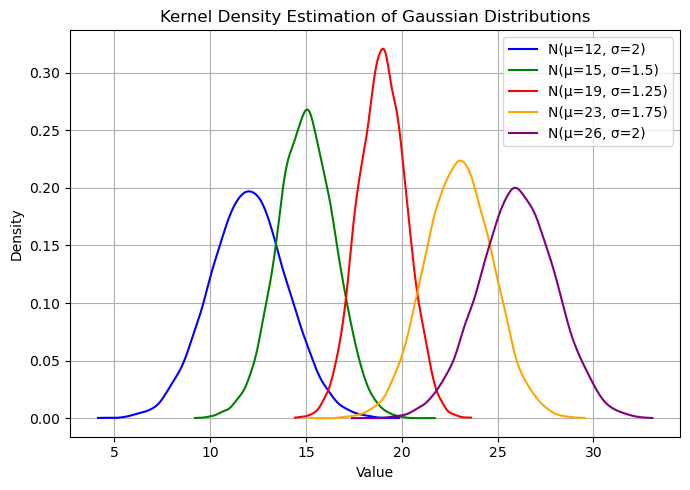

In [5]:
# Plot settings
COLORS = ["blue", "green", "red", "orange", "purple"]
labels = [f"N(μ={mean}, σ={std})" for mean, std in zip(MEANS, STDS)]

# Create figure
plt.figure(figsize=(7, 5))

# Plot KDE curves
for matrix, color, label in zip(gaussian_matrices, COLORS, labels):
    data = matrix.ravel()
    kde = stats.gaussian_kde(data)
    
    x_vals = np.linspace(data.min(), data.max(), 300)
    y_vals = kde(x_vals)
    
    plt.plot(x_vals, y_vals, color=color, label=label)

# Titles and labels
plt.title("Kernel Density Estimation of Gaussian Distributions")
plt.xlabel("Value")
plt.ylabel("Density")

# Layout
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Synthetic Datasets

We define two synthetic datasets built from Gaussian matrices:

- **SD1 (Simple Dataset 1):**  
  A column-structured dataset composed of five vertical regions. Each region is generated from a different Gaussian matrix, producing five distinct clusters distributed across the columns.

- **SD2 (Simple Dataset 2):**  
  A spatially structured dataset built from concentric circular regions. The background is initialized from the first Gaussian matrix, and nested circular areas are progressively filled with values from the other Gaussian matrices, creating five spatial clusters.

For each dataset, we store:
- the **data matrix**
- the associated **cluster labels**

These datasets are saved in a pickle file for reproducibility and reuse.

In [6]:
# Simple Dataset 1 (SD1)
sd1_data = np.zeros(SHAPE)
sd1_labels = np.full(SHAPE, -1, dtype=int)

for cluster_id in range(5):
    col_start = cluster_id * 20
    col_end = col_start + 20

    sd1_data[:, col_start:col_end] = gaussian_matrices[cluster_id][:, col_start:col_end]
    sd1_labels[:, col_start:col_end] = cluster_id

In [7]:
# Simple Dataset 2 (SD2)
ROWS, COLS = SHAPE

sd2_data = gaussian_matrices[0].copy()
sd2_labels = np.zeros((ROWS, COLS), dtype=int)  # Default background class

# Circle center
CENTER_X = 50
CENTER_Y = -20

# Decreasing radii associated with classes 1 to 4
RADII = [100, 80, 60, 40]

for cluster_id, radius in enumerate(RADII, start=1):
    source_matrix = gaussian_matrices[cluster_id]

    for x in range(ROWS):
        for y in range(COLS):
            distance = np.sqrt((x - CENTER_X) ** 2 + (y - CENTER_Y) ** 2)
            if distance < radius:
                sd2_data[x, y] = source_matrix[x, y]
                sd2_labels[x, y] = cluster_id

In [8]:
def summarize_cluster_statistics(data, labels, means, stds, dataset_name="Dataset"):
    """
    Compute and display target and empirical statistics for each cluster.

    Parameters
    ----------
    data : np.ndarray
        Data matrix.
    labels : np.ndarray
        Cluster label matrix with integer cluster IDs.
    means : list[float]
        Target mean for each cluster.
    stds : list[float]
        Target standard deviation for each cluster.
    dataset_name : str, optional
        Name of the dataset for display.

    Returns
    -------
    pd.DataFrame
        Summary table with rounded statistics.
    """
    summary = []

    n_clusters = len(means)

    for cluster_id in range(n_clusters):
        cluster_values = data[labels == cluster_id]

        summary.append(
            {
                "Cluster": cluster_id,
                "Target Mean": float(means[cluster_id]),
                "Empirical Mean": float(cluster_values.mean()),
                "Target Std": float(stds[cluster_id]),
                "Empirical Std": float(cluster_values.std()),
                "Samples": int(cluster_values.size),
            }
        )

    summary_df = pd.DataFrame(summary).round(2)

    display(
        summary_df.style
        .set_caption(f"{dataset_name} - Cluster Statistics")
        .format(
            {
                "Target Mean": "{:.2f}",
                "Empirical Mean": "{:.2f}",
                "Target Std": "{:.2f}",
                "Empirical Std": "{:.2f}",
            }
        )
    )

    return summary_df

In [9]:
sd1_stats_df = summarize_cluster_statistics(
    data=sd1_data,
    labels=sd1_labels,
    means=MEANS,
    stds=STDS,
    dataset_name="SD1",
)

,Cluster,Target Mean,Empirical Mean,Target Std,Empirical Std,Samples
0,0,12.00,11.99,2.00,2.01,2000
1,1,15.00,15.03,1.50,1.54,2000
2,2,19.00,18.95,1.25,1.24,2000
3,3,23.00,22.99,1.75,1.78,2000
4,4,26.00,25.98,2.00,1.94,2000


In [10]:
sd2_stats_df = summarize_cluster_statistics(
    data=sd2_data,
    labels=sd2_labels,
    means=MEANS,
    stds=STDS,
    dataset_name="SD2",
)

,Cluster,Target Mean,Empirical Mean,Target Std,Empirical Std,Samples
0,0,12.00,12.00,2.00,2.04,2389
1,1,15.00,14.98,1.50,1.50,2128
2,2,19.00,18.97,1.25,1.24,2239
3,3,23.00,22.96,1.75,1.77,2230
4,4,26.00,26.07,2.00,2.04,1014


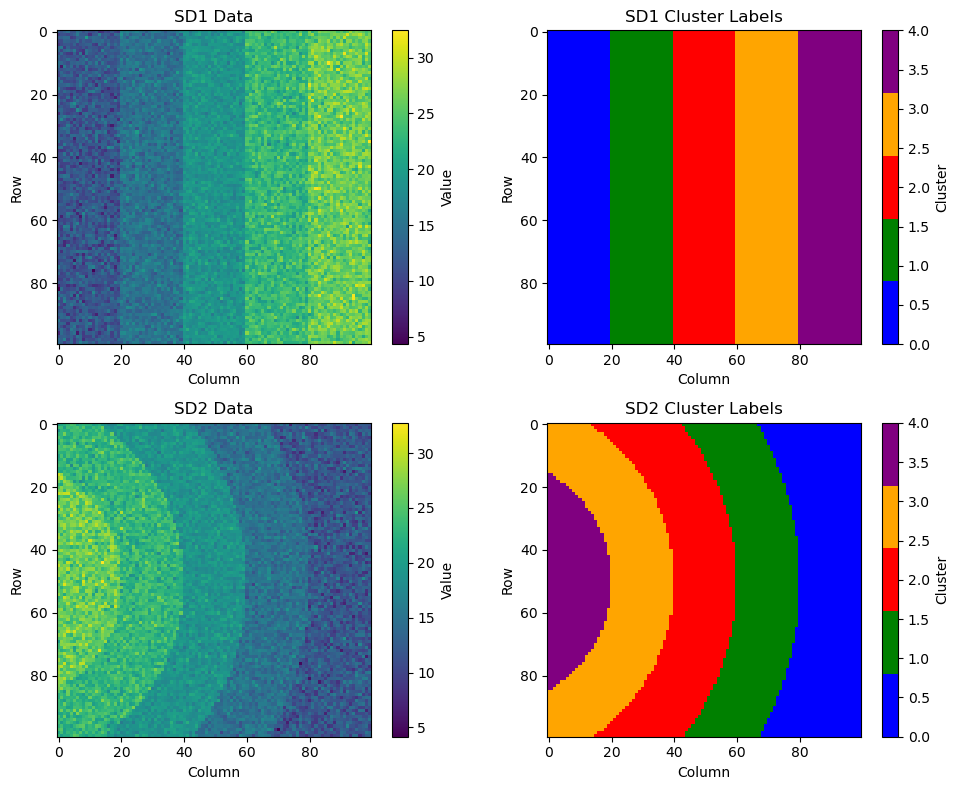

In [11]:


# Create a colormap using your defined COLORS
cluster_cmap = ListedColormap(COLORS)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# SD1 data
im0 = axes[0, 0].imshow(sd1_data)
axes[0, 0].set_title("SD1 Data")
plt.colorbar(im0, ax=axes[0, 0], label="Value")

# SD1 labels (use consistent colors)
im1 = axes[0, 1].imshow(sd1_labels, cmap=cluster_cmap, vmin=0, vmax=len(COLORS)-1)
axes[0, 1].set_title("SD1 Cluster Labels")
plt.colorbar(im1, ax=axes[0, 1], label="Cluster")

# SD2 data
im2 = axes[1, 0].imshow(sd2_data)
axes[1, 0].set_title("SD2 Data")
plt.colorbar(im2, ax=axes[1, 0], label="Value")

# SD2 labels (same colormap)
im3 = axes[1, 1].imshow(sd2_labels, cmap=cluster_cmap, vmin=0, vmax=len(COLORS)-1)
axes[1, 1].set_title("SD2 Cluster Labels")
plt.colorbar(im3, ax=axes[1, 1], label="Cluster")

for ax in axes.ravel():
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")

plt.tight_layout()
plt.show()

In [12]:
datasets = {
    "SD1": {
        "data": sd1_data,
        "labels": sd1_labels,
    },
    "SD2": {
        "data": sd2_data,
        "labels": sd2_labels,
    }
}

with open("simple_datasets.pkl", "wb") as file:
    pickle.dump(datasets, file)

## Geological Synthetic Datasets (GSD)

We generate geological synthetic datasets from reference images.

Each image is resized and converted into an RGB array. A KMeans clustering is then applied to the pixel values to identify five spatial regions. The resulting label maps are smoothed and reordered to improve spatial consistency.

For each cluster, Gaussian values are generated using predefined mean and standard deviation parameters. This produces a synthetic dataset associated with a ground-truth cluster map.

In [13]:
def smooth_labels_fast(label_matrix, radius=5):
    label_uint8 = label_matrix.astype(np.uint8)
    return modal(label_uint8, disk(radius))

In [14]:
def reorder_labels_by_spatial_proximity(label_matrix, n_labels=5):
    new_label_matrix = np.zeros_like(label_matrix)

    # 1. Trouver les centres de chaque cluster
    centers = np.array([center_of_mass(label_matrix == i) for i in range(n_labels)])

    # 2. Déterminer l'ordre spatial via plus proche voisin
    remaining = list(range(n_labels))
    ordered_labels = []
    current = remaining.pop(0)
    ordered_labels.append(current)

    while remaining:
        distances = cdist([centers[current]], centers[remaining])
        closest_idx = np.argmin(distances)
        current = remaining.pop(closest_idx)
        ordered_labels.append(current)

    # 3. Créer un mapping : ancien label → nouveau label
    label_mapping = {old: new for new, old in enumerate(ordered_labels)}

    # 4. Appliquer le mapping
    for old_label, new_label in label_mapping.items():
        new_label_matrix[label_matrix == old_label] = new_label

    return new_label_matrix

In [22]:
# Geological Synthetic Datasets (GSD)

# Image paths
BASE_PATH = "img_form_sup/format_sup_"
IMAGE_FILES = ["1.png", "2.png", "3.png", "4.png"]
IMAGE_SIZE = 100
N_CLUSTERS = 5

# Storage
gsd_datasets = []
gsd_label_matrices = []

for image_file in IMAGE_FILES:
    image_path = BASE_PATH + image_file
    image = Image.open(image_path)

    # Resize image and convert to RGB array
    image_resized = image.resize((IMAGE_SIZE, IMAGE_SIZE))
    image_array = np.asarray(image_resized.convert("RGB"))

    # Apply KMeans clustering on image pixels
    pixels = image_array.reshape(-1, 3)
    kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_SEED)
    pixel_labels = kmeans.fit_predict(pixels)

    # Build and post-process the label matrix
    label_matrix = pixel_labels.reshape((IMAGE_SIZE, IMAGE_SIZE))
    label_matrix = smooth_labels_fast(label_matrix, radius=5)
    label_matrix = reorder_labels_by_spatial_proximity(label_matrix, N_CLUSTERS)

    gsd_label_matrices.append(label_matrix)

    # Generate dataset values from Gaussian parameters associated with each cluster
    dataset = np.zeros((IMAGE_SIZE, IMAGE_SIZE))
    for cluster_id in range(N_CLUSTERS):
        mask = label_matrix == cluster_id
        dataset[mask] = np.random.normal(
            loc=MEANS[cluster_id],
            scale=STDS[cluster_id],
            size=np.sum(mask),
        )

    gsd_datasets.append(dataset)

In [23]:
gsd_bundle = {
    f"GSD{i + 1}": {
        "data": data,
        "labels": labels,
    }
    for i, (data, labels) in enumerate(zip(gsd_datasets, gsd_label_matrices))
}

with open("geological_synthetic_datasets.pkl", "wb") as file:
    pickle.dump(gsd_bundle, file)

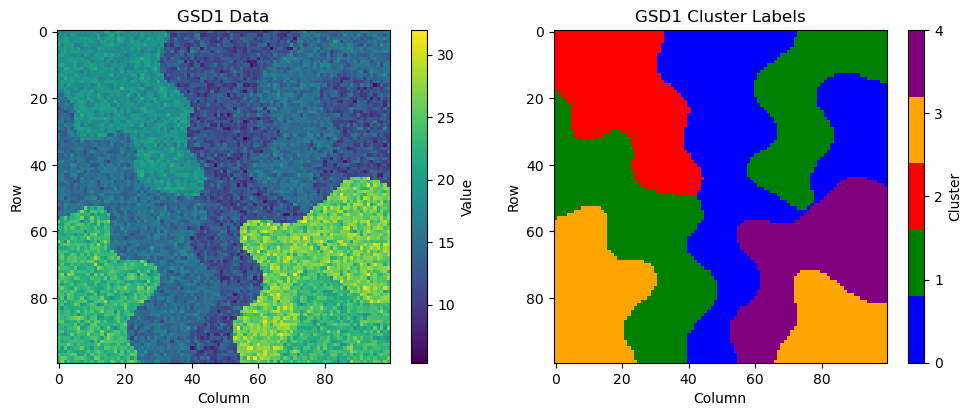

In [24]:
from matplotlib.colors import ListedColormap

CLUSTER_CMAP = ListedColormap(COLORS)

dataset_id = 0

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(gsd_datasets[dataset_id])
axes[0].set_title(f"GSD{dataset_id + 1} Data")
axes[0].set_xlabel("Column")
axes[0].set_ylabel("Row")
plt.colorbar(im0, ax=axes[0], label="Value")

im1 = axes[1].imshow(
    gsd_label_matrices[dataset_id],
    cmap=CLUSTER_CMAP,
    vmin=0,
    vmax=len(COLORS) - 1,
)
axes[1].set_title(f"GSD{dataset_id + 1} Cluster Labels")
axes[1].set_xlabel("Column")
axes[1].set_ylabel("Row")
cbar = plt.colorbar(im1, ax=axes[1], label="Cluster")
cbar.set_ticks(range(len(COLORS)))

plt.tight_layout()
plt.show()

In [25]:
gsd_stats_dfs = []

for i, (data, labels) in enumerate(zip(gsd_datasets, gsd_label_matrices), start=1):
    stats_df = summarize_cluster_statistics(
        data=data,
        labels=labels,
        means=MEANS,
        stds=STDS,
        dataset_name=f"GSD{i}",
    )
    
    gsd_stats_dfs.append(stats_df)

,Cluster,Target Mean,Empirical Mean,Target Std,Empirical Std,Samples
0,0,12.00,12.00,2.00,1.96,2720
1,1,15.00,15.00,1.50,1.55,2787
2,2,19.00,18.98,1.25,1.26,1375
3,3,23.00,23.01,1.75,1.76,1706
4,4,26.00,26.04,2.00,2.04,1412


,Cluster,Target Mean,Empirical Mean,Target Std,Empirical Std,Samples
0,0,12.00,12.05,2.00,2.01,2876
1,1,15.00,15.04,1.50,1.50,2286
2,2,19.00,19.00,1.25,1.25,1204
3,3,23.00,23.00,1.75,1.68,1684
4,4,26.00,25.99,2.00,1.97,1950


,Cluster,Target Mean,Empirical Mean,Target Std,Empirical Std,Samples
0,0,12.00,11.99,2.00,2.00,3055
1,1,15.00,14.98,1.50,1.50,2717
2,2,19.00,19.00,1.25,1.27,2690
3,3,23.00,23.01,1.75,1.83,699
4,4,26.00,26.10,2.00,1.98,839


,Cluster,Target Mean,Empirical Mean,Target Std,Empirical Std,Samples
0,0,12.00,12.02,2.00,2.02,2091
1,1,15.00,15.02,1.50,1.52,3085
2,2,19.00,18.99,1.25,1.23,3575
3,3,23.00,23.07,1.75,1.72,608
4,4,26.00,25.99,2.00,2.03,641
